In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/cleaned_telco.csv")
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


In [11]:
y = df["Churn Value"]
X = df.drop(columns=["Churn Value"])

In [12]:
y.value_counts(normalize=True)

Churn Value
0    0.734215
1    0.265785
Name: proportion, dtype: float64

In [13]:
def tenure_group(x):
    if x <= 12:
        return "Early"
    elif x <= 24:
        return "Mid"
    else:
        return "Long"

X["Tenure_Group"] = X["Tenure Months"].apply(tenure_group)

In [14]:
X["Charge_to_Tenure"] = X["Monthly Charges"] / (X["Tenure Months"] + 1)

In [17]:
service_cols = [
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies"
]

for col in service_cols:
    X[col] = X[col].map({"Yes": 1, "No": 0})

X["Service_Count"] = X[service_cols].sum(axis=1)

In [18]:
binary_cols = [
    "Partner",
    "Dependents",
    "Phone Service",
    "Paperless Billing",
    "Gender",
    "Senior Citizen"
]

for col in binary_cols:
    X[col] = X[col].map({"Yes": 1, "No": 0})

In [20]:
X["Gender"] = X["Gender"].map({"Male":1, "Female":0})

In [21]:
X.isnull().sum().sort_values(ascending=False).head(10)

Gender               7032
Online Security      7032
Online Backup        7032
Streaming TV         7032
Tech Support         7032
Device Protection    7032
Streaming Movies     7032
Churn Reason         5163
Partner                 0
Senior Citizen          0
dtype: int64

In [22]:
for col in service_cols:
    X[col] = X[col].apply(lambda x: 1 if x == "Yes" else 0)

In [23]:
X["Gender"] = X["Gender"].map({"Male": 1, "Female": 0})

In [24]:
X = X.drop(columns=["Churn Reason"])

In [25]:
X.isnull().sum().sort_values(ascending=False).head(10)

Gender              7032
Senior Citizen         0
Partner                0
Dependents             0
Tenure Months          0
Phone Service          0
Multiple Lines         0
Internet Service       0
Online Security        0
Online Backup          0
dtype: int64

In [30]:
X["Gender"].unique()

array(['Male', 'Female'], dtype=object)

In [31]:
X["Gender"] = X["Gender"].str.strip()
X["Gender"] = X["Gender"].map({"Male": 1, "Female": 0})

In [34]:
X.isnull().sum().sort_values(ascending=False).head(10)

Gender              0
Senior Citizen      0
Partner             0
Dependents          0
Tenure Months       0
Phone Service       0
Multiple Lines      0
Internet Service    0
Online Security     0
Online Backup       0
dtype: int64

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [38]:
print("Train distribution: ")
print(y_train.value_counts(normalize=True))

print("\nTest Distribution:")
print(y_test.value_counts(normalize=True))

Train distribution: 
Churn Value
0    0.734222
1    0.265778
Name: proportion, dtype: float64

Test Distribution:
Churn Value
0    0.734186
1    0.265814
Name: proportion, dtype: float64


In [39]:
X_train.dtypes

Gender                 int64
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges        float64
Churn Label           object
Churn Score            int64
CLTV                   int64
dtype: object

In [40]:
leakage_cols = ["Churn Label", "Churn Score", "CLTV"]

X = X.drop(columns=leakage_cols)

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [42]:
binary_cols = [
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Phone Service",
    "Paperless Billing"
]

for col in binary_cols:
    X[col] = X[col].apply(lambda x: 1 if x == "Yes" else 0)

In [43]:
X.dtypes

Gender                 int64
Senior Citizen         int64
Partner                int64
Dependents             int64
Tenure Months          int64
Phone Service          int64
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing      int64
Payment Method        object
Monthly Charges      float64
Total Charges        float64
dtype: object

In [44]:
num_cols = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges"
]

In [53]:
cat_cols = [
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Contract",
    "Payment Method",
]

In [54]:
binary_cols = [
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Phone Service",
    "Paperless Billing"
]

In [55]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [56]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("bin", "passthrough", binary_cols)
    ]
)

In [57]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [58]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

In [59]:
pipeline.fit(X_train, y_train)

ValueError: could not convert string to float: 'No'

In [52]:
print(X_train.columns)

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges'],
      dtype='object')


In [60]:
print(X_train.select_dtypes(include="object").columns)

Index(['Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method'],
      dtype='object')


In [62]:
set(X_train.select_dtypes(include="object").columns) - set(cat_cols)

{'Dependents',
 'Paperless Billing',
 'Partner',
 'Phone Service',
 'Senior Citizen'}

In [63]:
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()

In [65]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression

In [66]:
numeric_transformer = Pipeline(
    steps=[
        ("Scaler", StandardScaler())
    ]
)

In [67]:
categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [68]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [69]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

In [70]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [71]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

In [72]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("ROC_AUC: ", roc_auc_score(y_test, y_pred))

Accuracy:  0.806680881307747
Precision:  0.6448863636363636
Recall:  0.606951871657754
ROC_AUC:  0.7429725476391383


In [74]:
y_pred_adjusted = (y_prob > 0.4).astype(int)

In [76]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

print("Accuracy:", accuracy_score(y_test, y_pred_adjusted))
print("Precision:", precision_score(y_test, y_pred_adjusted))
print("Recall:", recall_score(y_test, y_pred_adjusted))

Accuracy: 0.783226723525231
Precision: 0.576837416481069
Recall: 0.6925133689839572


In [77]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

array([[908, 125],
       [147, 227]])

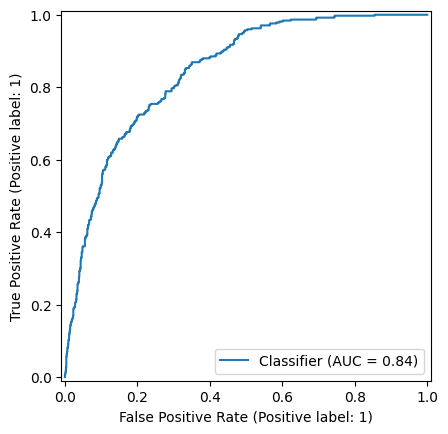

In [78]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, y_prob)

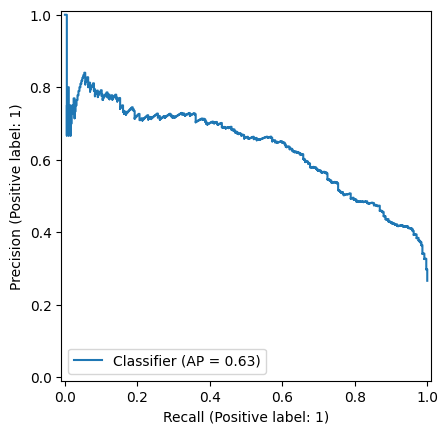

In [79]:
from sklearn.metrics import PrecisionRecallDisplay
PrecisionRecallDisplay.from_predictions(y_test, y_prob)

In [80]:
LogisticRegression(max_iter=1000, class_weight="balanced")

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [81]:
pipeline.named_steps["model"].coef_

array([[-1.94804912e-02, -1.37777750e+00,  1.47352462e-01,
         6.46640357e-01, -2.14056404e-01, -1.47366445e-01,
        -3.00709224e-01, -6.07136247e-02,  6.36068803e-01,
        -9.97491652e-01,  2.30786538e-02, -3.84501503e-01,
        -3.31411774e-01,  2.30786538e-02, -5.30897283e-02,
        -3.76393869e-01,  1.84559562e-01, -1.69588542e-01,
         1.29782907e-01, -1.69588542e-01, -3.21617214e-01,
         8.87765306e-03, -1.69588542e-01, -2.00711960e-01,
        -7.32510047e-02, -1.69588542e-01, -1.18583303e-01,
         1.21987871e-01, -1.69588542e-01, -3.13822179e-01,
        -1.92555850e-01, -1.69588542e-01,  7.21542332e-04,
        -1.69786884e-01, -1.69588542e-01, -2.20474230e-02,
         5.96827422e-01, -2.04691630e-01, -7.53558641e-01,
        -3.18943409e-01, -4.24794397e-02, -2.15031603e-01,
        -1.79570530e-01,  1.68381050e-01, -1.35201766e-01]])

In [82]:
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
coefs = pipeline.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs
}).sort_values(by="coefficient", ascending=False)

coef_df.head(10)

,feature,coefficient
3,num__Total Charges,0.646640
8,cat__Dependents_No,0.636069
36,cat__Contract_Month-to-month,0.596827
16,cat__Internet Service_Fiber optic,0.184560
43,cat__Payment Method_Electronic check,0.168381
2,num__Monthly Charges,0.147352
18,cat__Online Security_No,0.129783
27,cat__Tech Support_No,0.121988
13,cat__Multiple Lines_No phone service,0.023079
10,cat__Phone Service_No,0.023079


In [83]:
coef_df.tail(10)

,feature,coefficient
6,cat__Partner_No,-0.300709
29,cat__Tech Support_Yes,-0.313822
39,cat__Paperless Billing_No,-0.318943
20,cat__Online Security_Yes,-0.321617
12,cat__Multiple Lines_No,-0.331412
15,cat__Internet Service_DSL,-0.376394
11,cat__Phone Service_Yes,-0.384502
38,cat__Contract_Two year,-0.753559
9,cat__Dependents_Yes,-0.997492
1,num__Tenure Months,-1.377778
